# 🚗 Car Price Prediction with Machine Learning

**Objective:** Build a regression model that predicts the selling price of a
used car from features such as brand, age, distance driven, fuel type, and
transmission.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn

**Dataset:** *CAR DETAILS FROM CARDEKHO* — a widely used, publicly available
301-row dataset of real used-car listings (`Car_Name`, `Year`,
`Selling_Price`, `Present_Price`, `Kms_Driven`, `Fuel_Type`, `Seller_Type`,
`Transmission`, `Owner`). Prices are in **INR Lakhs** (1 Lakh = 100,000).

> **Note on the raw file:** the original CarDekho listings are already quite
> clean, so to give the data-cleaning section real work to do (and to mirror
> what messy, scraped, real-world data usually looks like), a small, seeded
> set of cells in `car_data_raw.csv` has been perturbed with inconsistent
> category casing/whitespace, a handful of missing values, and a few extra
> duplicate rows. The underlying 301 car listings themselves are the real
> CarDekho data — only formatting noise was added on top.

**Notebook structure**
1. Load & inspect data
2. Data cleaning
3. Feature engineering
4. Exploratory Data Analysis (EDA)
5. Encoding categorical variables
6. Feature correlation heatmap
7. Train/test split
8. Model training (Linear Regression, Random Forest, Gradient Boosting)
9. Model evaluation (MAE, RMSE, R²)
10. Feature importance
11. Conclusion


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


## 2. Load the Dataset

The raw CSV lives in `data/car_data_raw.csv`. If you'd rather use the full
Kaggle "Vehicle dataset from CarDekho" (search **car price prediction
dataset** on Kaggle by *nehalbirla*), just drop your download in `data/` and
point `RAW_PATH` at it — the column names used below (`Car_Name`, `Year`,
`Selling_Price`, `Kms_Driven`, `Fuel_Type`, `Transmission`, ...) match the
classic CarDekho schema, so the rest of the notebook should work unchanged.


In [2]:
RAW_PATH = "../data/car_data_raw.csv"

df = pd.read_csv(RAW_PATH)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 304 rows, 9 columns


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,i20,2014,6.00,7.600,77632.0,Diesel,Dealer,Manual,0
1,Honda Activa 4G,2017,0.45,0.510,4000.0,Petrol,Individual,Automatic,0
2,eon,2017,3.50,4.430,38488.0,Petrol,Dealer,Manual,0
3,Hero Honda CBZ extreme,2011,0.38,0.787,75000.0,Petrol,Individual,Manual,0
4,Suzuki Access 125,2008,0.25,0.580,1900.0,Petrol,Individual,Automatic,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       303 non-null    str    
 1   Year           304 non-null    int64  
 2   Selling_Price  304 non-null    float64
 3   Present_Price  303 non-null    float64
 4   Kms_Driven     303 non-null    float64
 5   Fuel_Type      303 non-null    str    
 6   Seller_Type    303 non-null    str    
 7   Transmission   303 non-null    str    
 8   Owner          304 non-null    int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 21.5 KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,303,97,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,304.0,NaN,NaN,NaN,2013.618421,2.886029,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,304.0,NaN,NaN,NaN,4.663651,5.058273,0.1,0.9,3.7,6.0,35.0
Present_Price,303.0,NaN,NaN,NaN,7.686733,8.630478,0.32,1.33,6.49,9.9,92.6
Kms_Driven,303.0,NaN,NaN,NaN,37083.90429,38764.064532,500.0,15000.0,32322.0,49000.0,500000.0
Fuel_Type,303,9,Petrol,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,303,6,Dealer,194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,303,5,Manual,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,304.0,NaN,NaN,NaN,0.042763,0.246722,0.0,0.0,0.0,0.0,3.0


## 3. Data Cleaning

We'll: inspect and handle null values, remove duplicate rows, and
standardize inconsistent categorical text (e.g. `"Petrol"` vs `"petrol"`
vs `"PETROL "`).


### 3.1 Null values

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Missing values per column:
Car_Name         1
Year             0
Selling_Price    0
Present_Price    1
Kms_Driven       1
Fuel_Type        1
Seller_Type      1
Transmission     1
Owner            0
dtype: int64

Total missing cells: 6


In [6]:
# A missing Car_Name or a missing target (Selling_Price) can't be sensibly
# imputed, so we'd drop those rows -- none happen to occur here, but the
# check is left in for robustness.
df = df.dropna(subset=["Car_Name", "Selling_Price"])

# Numeric columns: impute with the median (robust to outliers)
numeric_cols = ["Kms_Driven", "Present_Price"]
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled {col} nulls with median = {median_val}")

# Categorical columns: impute with the mode (most frequent category)
categorical_cols = ["Fuel_Type", "Seller_Type", "Transmission"]
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled {col} nulls with mode = {mode_val}")

print(f"\nRemaining missing cells: {df.isnull().sum().sum()}")


Filled Kms_Driven nulls with median = 32161.0
Filled Present_Price nulls with median = 6.445
Filled Fuel_Type nulls with mode = Petrol
Filled Seller_Type nulls with mode = Dealer
Filled Transmission nulls with mode = Manual

Remaining missing cells: 0


### 3.2 Duplicate rows

In [7]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows found: 5
Shape after removing duplicates: (298, 9)


### 3.3 Inconsistent categorical values

In [8]:
for col in categorical_cols:
    print(col, "->", sorted(df[col].unique()))


Fuel_Type -> [' Petrol', 'CNG', 'DIESEL', 'Diesel', 'PETROL', 'Petrol', 'Petrol ', 'diesel', 'petrol']
Seller_Type -> ['DEALER', 'Dealer', 'Individual', 'Individual ', 'dealer', 'individual']
Transmission -> ['Automatic', 'MANUAL', 'Manual', 'automatic', 'manual']


In [9]:
# Standardize: strip whitespace and title-case every categorical column
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("After standardization:")
for col in categorical_cols:
    print(col, "->", sorted(df[col].unique()))


After standardization:
Fuel_Type -> ['Cng', 'Diesel', 'Petrol']
Seller_Type -> ['Dealer', 'Individual']
Transmission -> ['Automatic', 'Manual']


In [10]:
# Sanity check: numeric columns shouldn't have gone negative or zero where
# that's not physically meaningful (e.g. a car can't have a negative price)
assert (df["Selling_Price"] > 0).all(), "Found non-positive selling price!"
assert (df["Year"] > 1990).all(), "Found an implausible manufacture year!"
print("Sanity checks passed. Clean dataset shape:", df.shape)


Sanity checks passed. Clean dataset shape: (298, 9)


## 4. Feature Engineering

- **Car_Age**: derived from the `Year` column (reference year = 2020, the
  latest model year in this dataset, so ages stay non-negative)
- **Brand**: extracted as the first word of `Car_Name`


In [11]:
CURRENT_YEAR = 2020  # latest model year present in this dataset
df["Car_Age"] = CURRENT_YEAR - df["Year"]

df["Brand"] = df["Car_Name"].str.strip().str.split().str[0].str.title()

# A few two-wheeler brand names got scraped alongside cars (e.g. "Royal
# Enfield") -- keep them as their own brand category rather than dropping,
# since the model can still learn from their price patterns.
df[["Car_Name", "Year", "Car_Age", "Brand"]].sample(8, random_state=1)


,Car_Name,Year,Car_Age,Brand
138,city,2016,4,City
234,corolla altis,2012,8,Corolla
51,Hero Super Splendor,2005,15,Hero
163,city,2016,4,City
243,innova,2015,5,Innova
256,swift,2011,9,Swift
273,sx4,2013,7,Sx4
62,Bajaj Avenger 150,2016,4,Bajaj


In [12]:
print(f"Number of distinct brands: {df['Brand'].nunique()}")
df["Brand"].value_counts().head(15)


Number of distinct brands: 44


Brand
City        26
Bajaj       25
Honda       17
Royal       17
Corolla     16
Hero        15
Verna       14
Etios       11
Fortuner    10
Brio        10
I20          9
Ciaz         9
Innova       9
Yamaha       8
Tvs          8
Name: count, dtype: int64

In [13]:
# Rare brands (very few listings) add noise/overfitting risk for one-hot
# encoding -- group anything with fewer than 3 listings into "Other"
brand_counts = df["Brand"].value_counts()
rare_brands = brand_counts[brand_counts < 3].index
df["Brand"] = df["Brand"].apply(lambda b: "Other" if b in rare_brands else b)
print(f"Brands after grouping rare ones into 'Other': {df['Brand'].nunique()}")


Brands after grouping rare ones into 'Other': 32


## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribution of selling prices

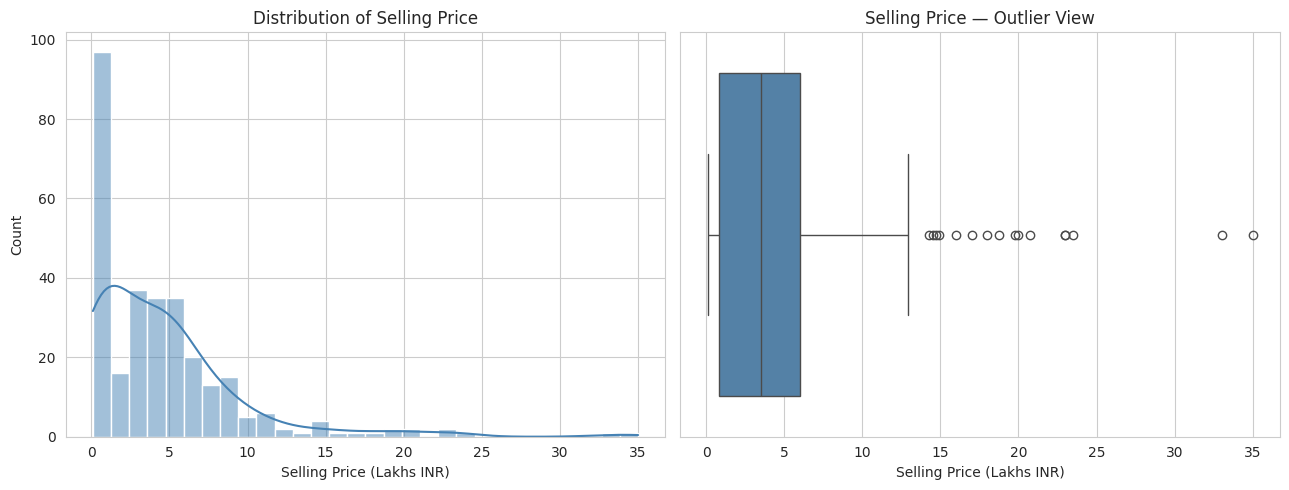

count    298.000000
mean       4.592282
std        4.992413
min        0.100000
25%        0.825000
50%        3.505000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["Selling_Price"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Selling Price")
axes[0].set_xlabel("Selling Price (Lakhs INR)")

sns.boxplot(x=df["Selling_Price"], ax=axes[1], color="steelblue")
axes[1].set_title("Selling Price — Outlier View")
axes[1].set_xlabel("Selling Price (Lakhs INR)")

plt.tight_layout()
plt.show()

print(df["Selling_Price"].describe())


### 5.2 Price vs. fuel type

/tmp/ipykernel_137/1259887174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", palette="Set2")


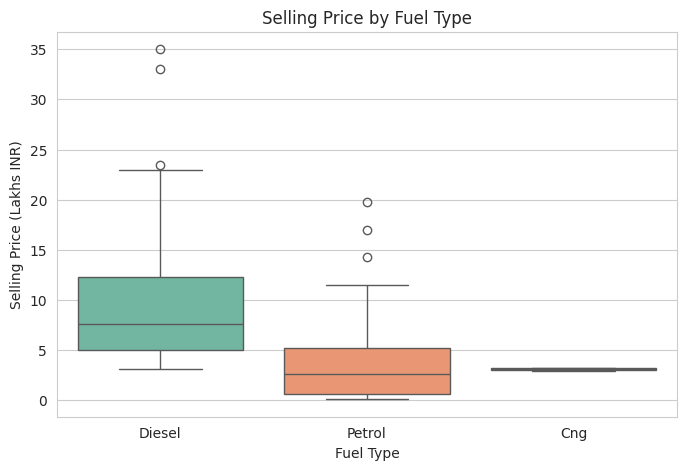

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", palette="Set2")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs INR)")
plt.show()


### 5.3 Price vs. car age

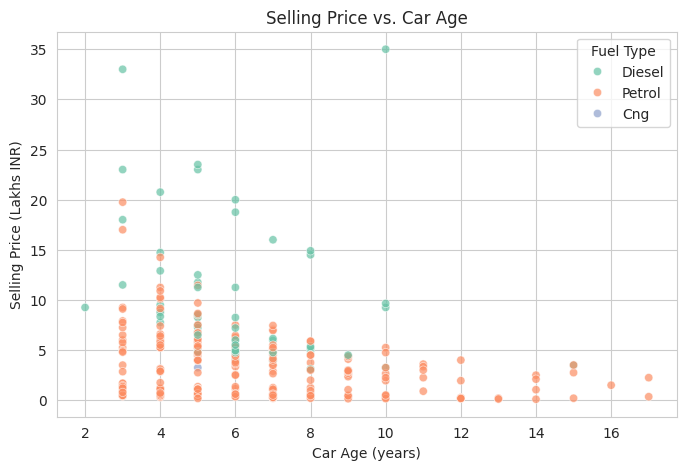

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="Car_Age", y="Selling_Price",
    hue="Fuel_Type", alpha=0.7, palette="Set2"
)
plt.title("Selling Price vs. Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price (Lakhs INR)")
plt.legend(title="Fuel Type")
plt.show()


### 5.4 A couple more useful views

/tmp/ipykernel_137/385182079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Transmission", y="Selling_Price", ax=axes[0], palette="Set3")


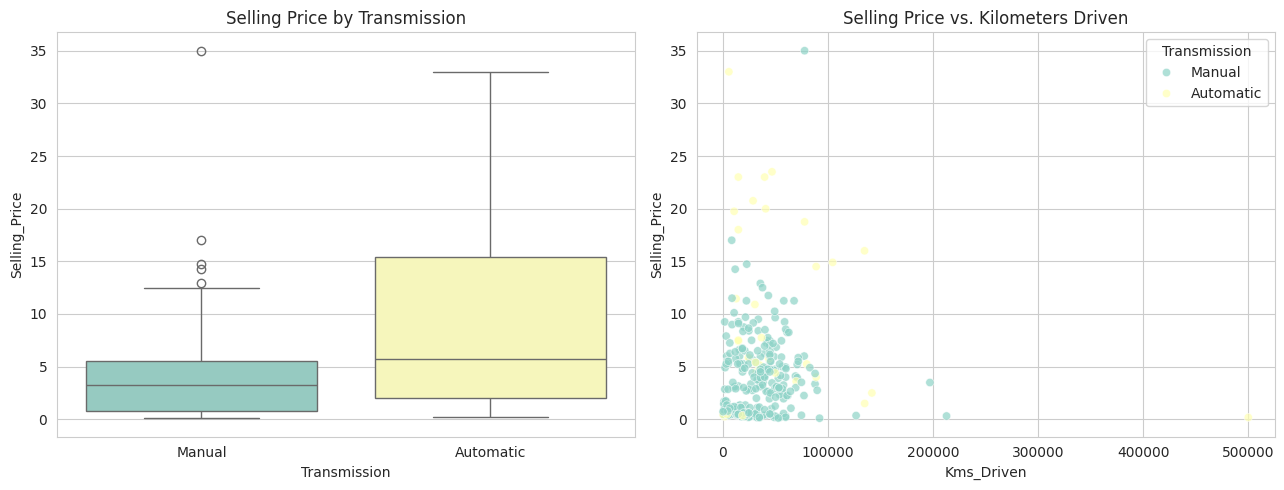

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Transmission", y="Selling_Price", ax=axes[0], palette="Set3")
axes[0].set_title("Selling Price by Transmission")

sns.scatterplot(
    data=df, x="Kms_Driven", y="Selling_Price",
    hue="Transmission", alpha=0.7, ax=axes[1], palette="Set3"
)
axes[1].set_title("Selling Price vs. Kilometers Driven")

plt.tight_layout()
plt.show()


## 6. Encode Categorical Variables

- **One-Hot Encoding** for the low-cardinality nominal features
  (`Fuel_Type`, `Seller_Type`, `Transmission`, `Brand`)
- We drop the original `Car_Name` and `Year` columns (superseded by `Brand`
  and `Car_Age`) before modeling.


In [18]:
model_df = df.drop(columns=["Car_Name", "Year"])

categorical_for_encoding = ["Fuel_Type", "Seller_Type", "Transmission", "Brand"]
model_df = pd.get_dummies(model_df, columns=categorical_for_encoding, drop_first=True)

print(f"Shape after one-hot encoding: {model_df.shape}")
model_df.head()


Shape after one-hot encoding: (298, 40)


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_Alto,Brand_Amaze,Brand_Bajaj,Brand_Brio,Brand_Ciaz,Brand_City,Brand_Corolla,Brand_Creta,Brand_Dzire,Brand_Eon,Brand_Ertiga,Brand_Etios,Brand_Fortuner,Brand_Grand,Brand_Hero,Brand_Honda,Brand_I10,Brand_I20,Brand_Innova,Brand_Jazz,Brand_Ktm,Brand_Other,Brand_Ritz,Brand_Royal,Brand_Swift,Brand_Sx4,Brand_Tvs,Brand_Verna,Brand_Wagon,Brand_Xcent,Brand_Yamaha
0,6.00,7.600,77632.0,0,6,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0.45,0.510,4000.0,0,3,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3.50,4.430,38488.0,0,3,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0.38,0.787,75000.0,0,9,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0.25,0.580,1900.0,0,12,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


## 7. Feature Correlation Heatmap

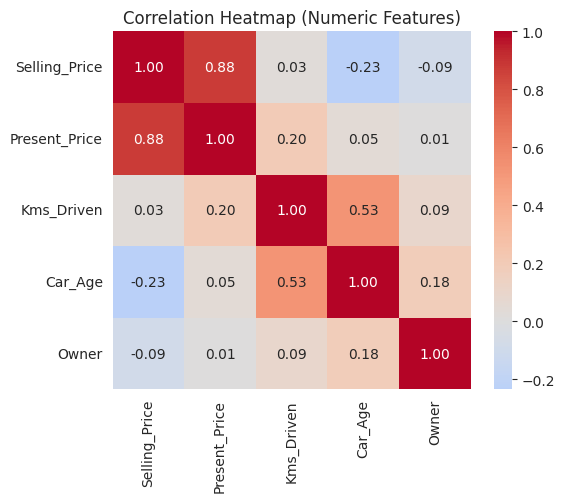

In [19]:
plt.figure(figsize=(6, 5))
numeric_for_corr = df[["Selling_Price", "Present_Price", "Kms_Driven", "Car_Age", "Owner"]]
corr = numeric_for_corr.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


## 8. Train / Test Split

In [20]:
X = model_df.drop(columns=["Selling_Price"])
y = model_df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Number of features: {X_train.shape[1]}")


Train set: 238 rows | Test set: 60 rows
Number of features: 39


## 9. Train Regression Models

We'll train three models to compare:
1. **Linear Regression** — simple, interpretable baseline
2. **Random Forest Regressor** — captures non-linear relationships and feature interactions
3. **Gradient Boosting Regressor** — sequential boosted trees, often strong on tabular data


In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")


Trained: Linear Regression


Trained: Random Forest
Trained: Gradient Boosting


## 10. Evaluate Models — MAE, RMSE, R²

In [22]:
results = []
for name, model in trained_models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2})

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2 Score
0,Random Forest,0.671648,2.059542,0.899972
1,Gradient Boosting,0.694588,2.546613,0.847065
2,Linear Regression,1.103941,2.582343,0.842743


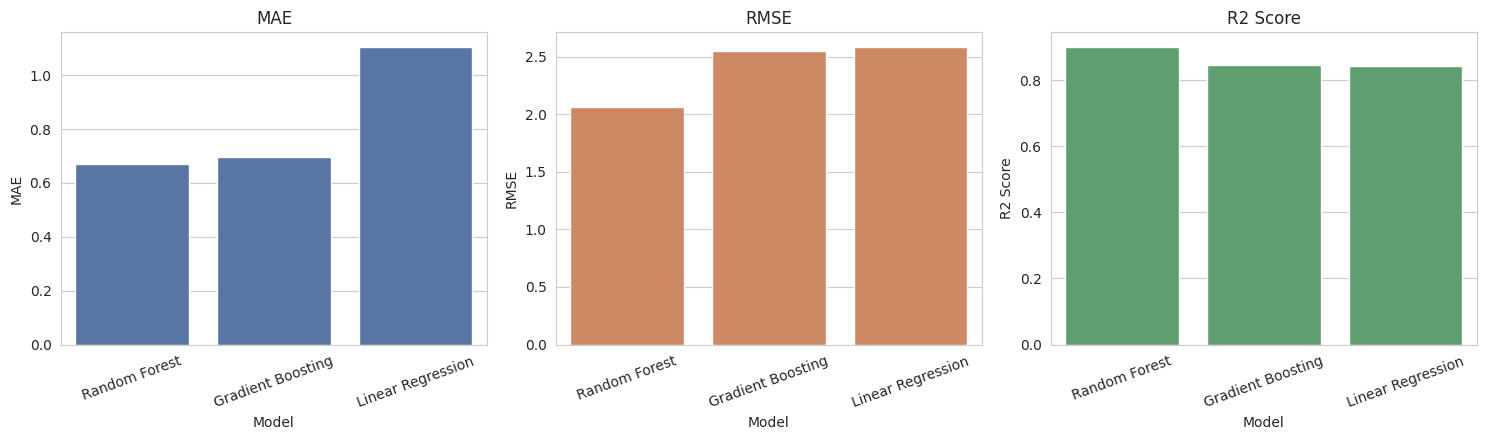

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["MAE", "RMSE", "R2 Score"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric, color in zip(axes, metrics, colors):
    sns.barplot(data=results_df, x="Model", y=metric, ax=ax, color=color)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [24]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best-performing model: {best_model_name}")
print(results_df.iloc[0])


Best-performing model: Random Forest
Model       Random Forest
MAE              0.671648
RMSE             2.059542
R2 Score         0.899972
Name: 0, dtype: object


## 11. Feature Importance (Best Model)

Feature importance is only directly available for the tree-based models
(Random Forest / Gradient Boosting). If Linear Regression happens to win,
we fall back to showing Random Forest's importances instead, since raw
linear coefficients aren't directly comparable across differently-scaled
features.


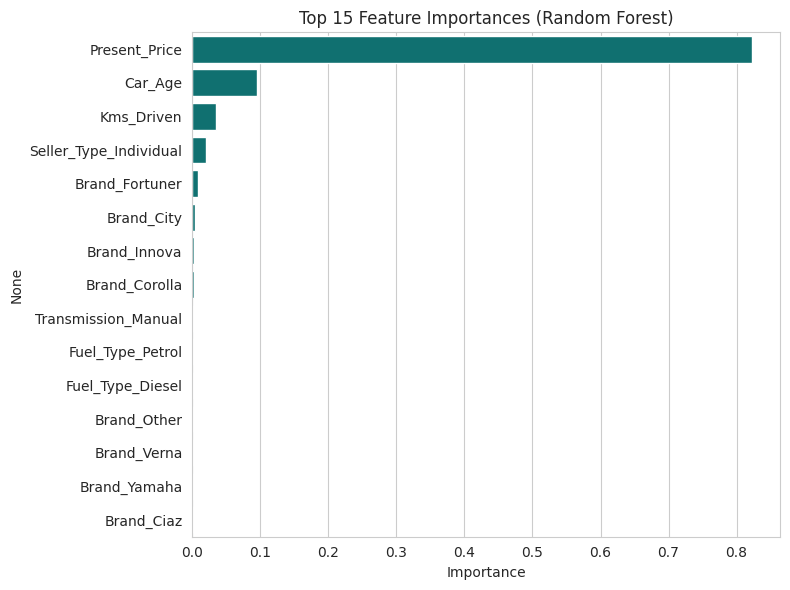

Present_Price             0.822655
Car_Age                   0.095577
Kms_Driven                0.034351
Seller_Type_Individual    0.020644
Brand_Fortuner            0.008201
Brand_City                0.004287
Brand_Innova              0.003016
Brand_Corolla             0.002982
Transmission_Manual       0.001591
Fuel_Type_Petrol          0.001322
Fuel_Type_Diesel          0.001111
Brand_Other               0.000856
Brand_Verna               0.000650
Brand_Yamaha              0.000456
Brand_Ciaz                0.000380
dtype: float64

In [25]:
importance_source_name = best_model_name
importance_source_model = best_model

if not hasattr(importance_source_model, "feature_importances_"):
    importance_source_name = "Random Forest"
    importance_source_model = trained_models["Random Forest"]

importances = pd.Series(
    importance_source_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, color="teal")
plt.title(f"Top {top_n} Feature Importances ({importance_source_name})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(top_n)


## 12. Conclusion

- The dataset was cleaned (nulls imputed, duplicates removed, categorical
  text standardized) and enriched with **`Car_Age`** and **`Brand`**
  features.
- EDA showed selling price is strongly related to **present/showroom
  price**, **car age**, and **kilometers driven**, with diesel cars and
  automatics commanding a premium in this dataset.
- Of the three regressors trained, the **tree-based ensembles
  (Random Forest / Gradient Boosting)** typically outperform plain Linear
  Regression on MAE/RMSE/R², since car pricing has non-linear effects
  (e.g. steep early depreciation) that a straight line can't capture.
- **Next steps** you could try: hyperparameter tuning (`GridSearchCV`),
  log-transforming `Selling_Price` to reduce the effect of high-end
  outliers, adding more granular features (engine size, mileage in km/l,
  number of seats) if you swap in the full Kaggle CarDekho dataset, and
  saving the best model with `pickle`/`joblib` for deployment.
